# Matrix-Multiplication Neural Network in NumPy

This notebook rewrites the neural network as pure matrix multiplication and elementwise operations.

Design goals:
- build the input with all numerical features plus binary bag-of-words features
- keep the same leakage-safe split logic from the EDA notebook
- implement forward propagation, backpropagation, and parameter updates manually with `numpy`
- produce `softmax` probabilities and one-hot column-vector outputs
- report F1 score, recall, and accuracy


## Step 1. Import packages and define experiment settings

This notebook uses `pandas` for data handling, `numpy` for all matrix operations, and `matplotlib` for visualization.

In [1]:
from __future__ import annotations

import random
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
BATCH_SIZE = 64
MAX_EPOCHS = 80
PATIENCE = 12
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = (128, 64)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(SEED)


## Step 2. Load and clean the dataset

We keep the same cleaned column names as before. We parse Likert responses into numbers and convert the free-form price field into a numeric `price_clean` column.

In [2]:
RENAME_MAP = {
    "Painting": "painting",
    "On a scale of 1–10, how intense is the emotion conveyed by the artwork?": "emotion_rating",
    "Describe how this painting makes you feel.": "feel_describe",
    "This art piece makes me feel sombre.": "sombre",
    "This art piece makes me feel content.": "content",
    "This art piece makes me feel calm.": "calm",
    "This art piece makes me feel uneasy.": "uneasy",
    "How many prominent colours do you notice in this painting?": "colors",
    "How many objects caught your eye in the painting?": "objects",
    "How much (in Canadian dollars) would you be willing to pay for this painting?": "price",
    "If you could purchase this painting, which room would you put that painting in?": "room",
    "If you could view this art in person, who would you want to view it with?": "exhibition_with",
    "What season does this art piece remind you of?": "season",
    "If this painting was a food, what would be?": "food",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.": "soundtrack",
}

LIKERT_COLS = ["sombre", "content", "calm", "uneasy"]


def extract_likert_value(value: object) -> float:
    if pd.isna(value):
        return np.nan
    match = re.match(r"^(\d+)", str(value).strip())
    return float(match.group(1)) if match else np.nan


def parse_price_value(value: object) -> float:
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip().replace(",", "")
    if not text:
        return np.nan

    range_match = re.search(r"(\d+\.?\d*)\s*(?:-|–|to)\s*(\d+\.?\d*)", text)
    if range_match:
        low, high = float(range_match.group(1)), float(range_match.group(2))
        return (low + high) / 2

    for pattern, multiplier in (
        (r"(\d+\.?\d*)\s*(?:billion|bn|b)\b", 1_000_000_000),
        (r"(\d+\.?\d*)\s*(?:million|m)\b", 1_000_000),
        (r"(\d+\.?\d*)\s*k\b", 1_000),
    ):
        mult_match = re.search(pattern, text)
        if mult_match:
            return float(mult_match.group(1)) * multiplier

    first_num = re.search(r"(\d+\.?\d*)", text)
    if first_num:
        return float(first_num.group(1))

    return np.nan


def load_clean_data(csv_path: str = "training_data_202601.csv") -> pd.DataFrame:
    data = pd.read_csv(csv_path).rename(columns=RENAME_MAP)
    data["unique_id"] = data["unique_id"].astype(str)
    data["painting"] = data["painting"].astype(str)

    for col in ["emotion_rating", "colors", "objects"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    for col in LIKERT_COLS:
        data[col] = data[col].apply(extract_likert_value)

    data["price_clean"] = data["price"].apply(parse_price_value)
    return data


raw_data = load_clean_data()
print("Dataset shape:", raw_data.shape)
print("Class counts:")
print(raw_data["painting"].value_counts())
raw_data.head()


Dataset shape: (1686, 17)
Class counts:
painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,painting,emotion_rating,feel_describe,sombre,content,calm,uneasy,colors,objects,price,room,exhibition_with,season,food,soundtrack,price_clean
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4.0,3.0,2.0,1.0,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...,0.0
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4.0,1.0,1.0,4.0,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...,5.0
3,4,The Persistence of Memory,7.0,Deflated,4.0,1.0,2.0,4.0,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q,NaN
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3.0,4.0,5.0,3.0,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.,300.0


## Step 3. Create a leakage-safe train, validation, and test split

Following the EDA notebook, we split by `unique_id` so the same respondent never appears in multiple splits.

In [3]:
def group_train_val_test_split(
    data: pd.DataFrame,
    seed: int = SEED,
    train_val_ratio: float = 0.8,
    train_ratio_within_train_val: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    unique_ids = data["unique_id"].dropna().unique()
    unique_ids = np.array(unique_ids)
    rng.shuffle(unique_ids)

    train_val_cut = int(len(unique_ids) * train_val_ratio)
    train_val_ids = unique_ids[:train_val_cut]
    test_ids = unique_ids[train_val_cut:]

    train_cut = int(len(train_val_ids) * train_ratio_within_train_val)
    train_ids = set(train_val_ids[:train_cut])
    val_ids = set(train_val_ids[train_cut:])
    test_ids = set(test_ids)

    train_df = data[data["unique_id"].isin(train_ids)].copy().reset_index(drop=True)
    val_df = data[data["unique_id"].isin(val_ids)].copy().reset_index(drop=True)
    test_df = data[data["unique_id"].isin(test_ids)].copy().reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = group_train_val_test_split(raw_data)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_id_count": [
            train_df["unique_id"].nunique(),
            val_df["unique_id"].nunique(),
            test_df["unique_id"].nunique(),
        ],
    }
)
split_summary


,split,rows,unique_id_count
0,train,1077,359
1,validation,270,90
2,test,339,113


## Step 4. Build the input vector with pandas and NumPy only

We keep the same feature idea as the bag-of-words notebook, but we implement everything manually with `pandas` and `numpy`.

Input blocks:
- all numerical features
- binary bag-of-words features for all word-based columns

For each word-based column, we build the vocabulary only from the training split. Then each sample receives a binary vector: `1` if the word appears in that column, `0` otherwise.

In [4]:
NUMERIC_COLS = ["emotion_rating", *LIKERT_COLS, "colors", "objects", "price_clean"]
WORD_COLS = ["room", "exhibition_with", "season", "feel_describe", "food", "soundtrack"]
WORD_PATTERN = re.compile(r"[A-Za-z']+")


@dataclass
class PreparedData:
    X_train: np.ndarray
    X_val: np.ndarray
    X_test: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    class_names: list[str]
    vocab_sizes: dict[str, int]


def extract_words(value: object) -> set[str]:
    if pd.isna(value):
        return set()
    return set(WORD_PATTERN.findall(str(value).lower()))


def build_vocabulary(series: pd.Series) -> dict[str, int]:
    vocab = sorted({word for value in series.fillna("") for word in extract_words(value)})
    return {word: idx for idx, word in enumerate(vocab)}


def encode_binary_bow(series: pd.Series, vocabulary: dict[str, int]) -> np.ndarray:
    matrix = np.zeros((len(series), len(vocabulary)), dtype=np.float32)
    for row_idx, value in enumerate(series.fillna("")):
        for word in extract_words(value):
            col_idx = vocabulary.get(word)
            if col_idx is not None:
                matrix[row_idx, col_idx] = 1.0
    return matrix


def build_input_features(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> PreparedData:
    train_num = train_df[NUMERIC_COLS].copy()
    val_num = val_df[NUMERIC_COLS].copy()
    test_num = test_df[NUMERIC_COLS].copy()

    train_medians = train_num.median(numeric_only=True)
    train_num = train_num.fillna(train_medians)
    val_num = val_num.fillna(train_medians)
    test_num = test_num.fillna(train_medians)

    price_cap = float(train_num["price_clean"].quantile(0.99))
    for frame in (train_num, val_num, test_num):
        frame["price_clean"] = frame["price_clean"].clip(lower=0, upper=price_cap)
        frame["price_clean"] = np.log1p(frame["price_clean"])

    train_means = train_num.mean()
    train_stds = train_num.std().replace(0, 1)

    X_train_num = ((train_num - train_means) / train_stds).to_numpy(dtype=np.float32)
    X_val_num = ((val_num - train_means) / train_stds).to_numpy(dtype=np.float32)
    X_test_num = ((test_num - train_means) / train_stds).to_numpy(dtype=np.float32)

    train_parts = [X_train_num]
    val_parts = [X_val_num]
    test_parts = [X_test_num]
    vocab_sizes = {}

    for col in WORD_COLS:
        vocabulary = build_vocabulary(train_df[col])
        train_parts.append(encode_binary_bow(train_df[col], vocabulary))
        val_parts.append(encode_binary_bow(val_df[col], vocabulary))
        test_parts.append(encode_binary_bow(test_df[col], vocabulary))
        vocab_sizes[col] = len(vocabulary)

    X_train = np.concatenate(train_parts, axis=1).astype(np.float32)
    X_val = np.concatenate(val_parts, axis=1).astype(np.float32)
    X_test = np.concatenate(test_parts, axis=1).astype(np.float32)

    class_names = sorted(train_df["painting"].unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}

    y_train = train_df["painting"].map(class_to_index).to_numpy()
    y_val = val_df["painting"].map(class_to_index).to_numpy()
    y_test = test_df["painting"].map(class_to_index).to_numpy()

    return PreparedData(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        class_names=class_names,
        vocab_sizes=vocab_sizes,
    )


## Step 5. Inspect the final input dimension

At this point, every sample has been converted into one fully concatenated input vector.

In [5]:
prepared = build_input_features(train_df, val_df, test_df)
print("Training matrix shape:", prepared.X_train.shape)
print("Validation matrix shape:", prepared.X_val.shape)
print("Test matrix shape:", prepared.X_test.shape)
print("Class order:", prepared.class_names)
print("Vocabulary sizes:")
print(prepared.vocab_sizes)


Training matrix shape: (1077, 4832)
Validation matrix shape: (270, 4832)
Test matrix shape: (339, 4832)
Class order: ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']
Vocabulary sizes:
{'room': 6, 'exhibition_with': 8, 'season': 4, 'feel_describe': 1937, 'food': 925, 'soundtrack': 1944}


## Step 6. Rewrite the neural network as matrix multiplication

Instead of using PyTorch layers, we write the network directly with matrices:

- `Z1 = X @ W1 + b1`
- `A1 = ReLU(Z1)`
- `Z2 = A1 @ W2 + b2`
- `A2 = ReLU(Z2)`
- `Z3 = A2 @ W3 + b3`
- `Y_hat = softmax(Z3)`

This notebook uses a lighter 2-hidden-layer MLP to keep the pure NumPy implementation transparent and runnable.

In [6]:
def one_hot(y: np.ndarray, num_classes: int) -> np.ndarray:
    matrix = np.zeros((len(y), num_classes), dtype=np.float32)
    matrix[np.arange(len(y)), y] = 1.0
    return matrix


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)


def relu_grad(x: np.ndarray) -> np.ndarray:
    return (x > 0).astype(np.float32)


def softmax(z: np.ndarray) -> np.ndarray:
    shifted = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def accuracy_score_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(y_true == y_pred))


def macro_f1_and_recall(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> tuple[float, float]:
    f1_values = []
    recall_values = []

    for cls in range(num_classes):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        f1_values.append(f1)
        recall_values.append(recall)

    return float(np.mean(f1_values)), float(np.mean(recall_values))


In [7]:
class NumpyMLP:
    def __init__(self, input_dim: int, hidden_dims: tuple[int, ...], output_dim: int) -> None:
        dims = [input_dim, *hidden_dims, output_dim]
        self.W = []
        self.b = []

        for dim_in, dim_out in zip(dims[:-1], dims[1:]):
            scale = np.sqrt(2.0 / dim_in)
            self.W.append((np.random.randn(dim_in, dim_out) * scale).astype(np.float32))
            self.b.append(np.zeros((1, dim_out), dtype=np.float32))

    def forward(self, X: np.ndarray) -> tuple[np.ndarray, tuple[np.ndarray, ...]]:
        Z1 = X @ self.W[0] + self.b[0]
        A1 = relu(Z1)
        Z2 = A1 @ self.W[1] + self.b[1]
        A2 = relu(Z2)
        Z3 = A2 @ self.W[2] + self.b[2]
        probabilities = softmax(Z3)
        cache = (X, Z1, A1, Z2, A2, Z3, probabilities)
        return probabilities, cache

    def backward(self, cache: tuple[np.ndarray, ...], targets_one_hot: np.ndarray) -> tuple[list[np.ndarray], list[np.ndarray]]:
        X, Z1, A1, Z2, A2, Z3, probabilities = cache
        batch_size = X.shape[0]

        dZ3 = (probabilities - targets_one_hot) / batch_size
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = dZ3 @ self.W[2].T
        dZ2 = dA2 * relu_grad(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W[1].T
        dZ1 = dA1 * relu_grad(Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        return [dW1, dW2, dW3], [db1, db2, db3]

    def step(self, dW: list[np.ndarray], db: list[np.ndarray], learning_rate: float, weight_decay: float) -> None:
        for idx in range(len(self.W)):
            self.W[idx] -= learning_rate * (dW[idx] + weight_decay * self.W[idx])
            self.b[idx] -= learning_rate * db[idx]


def train_model(
    model: NumpyMLP,
    prepared: PreparedData,
    epochs: int = MAX_EPOCHS,
    batch_size: int = BATCH_SIZE,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = PATIENCE,
) -> tuple[NumpyMLP, pd.DataFrame, int]:
    num_classes = len(prepared.class_names)
    y_train_one_hot = one_hot(prepared.y_train, num_classes)

    best_weights = None
    best_biases = None
    best_val_f1 = -np.inf
    best_epoch = 0
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        permutation = np.random.permutation(len(prepared.X_train))
        X_shuffled = prepared.X_train[permutation]
        y_shuffled = y_train_one_hot[permutation]

        for start in range(0, len(X_shuffled), batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            probabilities, cache = model.forward(X_batch)
            dW, db = model.backward(cache, y_batch)
            model.step(dW, db, learning_rate, weight_decay)

        val_probabilities, _ = model.forward(prepared.X_val)
        val_predictions = val_probabilities.argmax(axis=1)
        val_accuracy = accuracy_score_np(prepared.y_val, val_predictions)
        val_f1, val_recall = macro_f1_and_recall(prepared.y_val, val_predictions, num_classes)

        history.append(
            {
                "epoch": epoch,
                "val_accuracy": val_accuracy,
                "val_f1": val_f1,
                "val_recall": val_recall,
            }
        )

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_weights = [weight.copy() for weight in model.W]
            best_biases = [bias.copy() for bias in model.b]
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.W = [weight.copy() for weight in best_weights]
    model.b = [bias.copy() for bias in best_biases]
    return model, pd.DataFrame(history), best_epoch


def evaluate_model(model: NumpyMLP, X: np.ndarray, y: np.ndarray, class_names: list[str]) -> dict[str, object]:
    probabilities, _ = model.forward(X)
    predictions = probabilities.argmax(axis=1)
    accuracy = accuracy_score_np(y, predictions)
    f1, recall = macro_f1_and_recall(y, predictions, len(class_names))
    one_hot_columns = one_hot(predictions, len(class_names)).T
    return {
        "accuracy": accuracy,
        "f1_macro": f1,
        "recall_macro": recall,
        "probabilities": probabilities,
        "predictions": predictions,
        "one_hot_columns": one_hot_columns,
    }


## Step 7. Train the NumPy neural network and report metrics

We now train the matrix-multiplication network with mini-batch gradient descent and keep the best checkpoint based on validation macro-F1.

In [8]:
set_seed(SEED)
model = NumpyMLP(
    input_dim=prepared.X_train.shape[1],
    hidden_dims=HIDDEN_DIMS,
    output_dim=len(prepared.class_names),
)

model, training_history, best_epoch = train_model(model, prepared)

val_result = evaluate_model(model, prepared.X_val, prepared.y_val, prepared.class_names)
test_result = evaluate_model(model, prepared.X_test, prepared.y_test, prepared.class_names)

print("Best epoch:", best_epoch)
print()
print("Validation metrics")
print(f"accuracy: {val_result['accuracy']:.4f}")
print(f"f1_macro: {val_result['f1_macro']:.4f}")
print(f"recall_macro: {val_result['recall_macro']:.4f}")
print()
print("Test metrics")
print(f"accuracy: {test_result['accuracy']:.4f}")
print(f"f1_macro: {test_result['f1_macro']:.4f}")
print(f"recall_macro: {test_result['recall_macro']:.4f}")


Best epoch: 37

Validation metrics
accuracy: 0.8926
f1_macro: 0.8936
recall_macro: 0.8926

Test metrics
accuracy: 0.8968
f1_macro: 0.8967
recall_macro: 0.8968


## Step 8. Inspect the softmax output and the one-hot column vector

The final layer produces `softmax` probabilities. We then convert the predicted class into a one-hot column vector.

In [9]:
print("Softmax probability matrix shape:", test_result["probabilities"].shape)
print("One-hot column matrix shape:", test_result["one_hot_columns"].shape)
print()
print("First test sample softmax output:")
print(np.round(test_result["probabilities"][0], 4))
print()
print("First test sample one-hot column vector:")
print(test_result["one_hot_columns"][:, 0].astype(int))
print()
print("Predicted class for the first test sample:")
print(prepared.class_names[test_result["predictions"][0]])


Softmax probability matrix shape: (339, 3)
One-hot column matrix shape: (3, 339)

First test sample softmax output:
[0.9872 0.006  0.0068]

First test sample one-hot column vector:
[1 0 0]

Predicted class for the first test sample:
The Persistence of Memory


## Step 9. Plot confusion matrices without sklearn

We build confusion matrices manually with NumPy and visualize them with `matplotlib`.

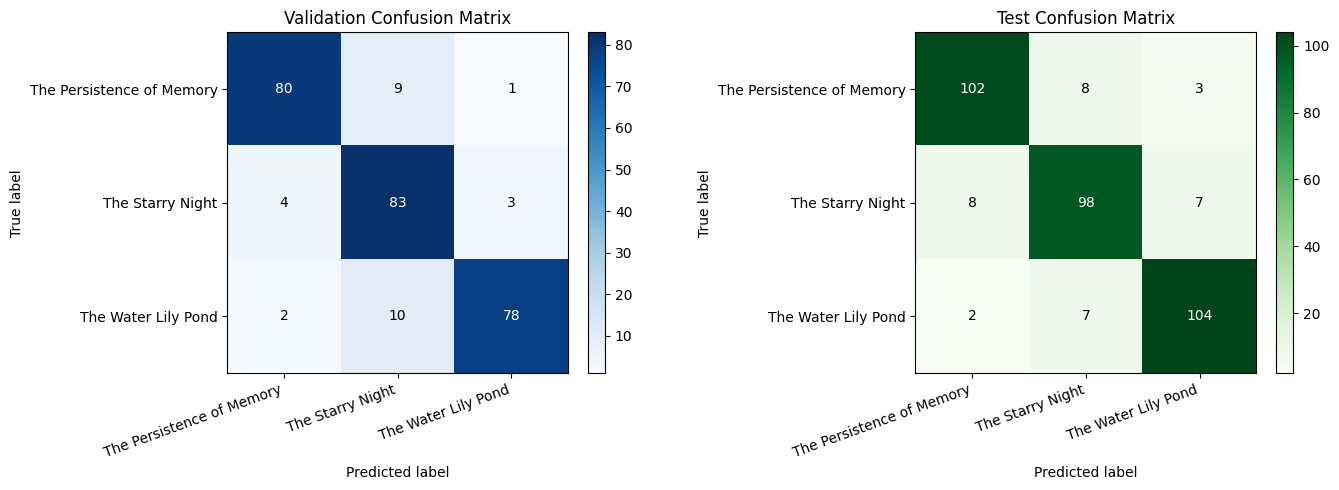

In [10]:
def build_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        matrix[true_label, pred_label] += 1
    return matrix


def plot_confusion_matrix(ax, matrix: np.ndarray, class_names: list[str], title: str, cmap: str) -> None:
    image = ax.imshow(matrix, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=20, ha="right")
    ax.set_yticklabels(class_names)

    threshold = matrix.max() / 2 if matrix.max() > 0 else 0
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            color = "white" if matrix[row_idx, col_idx] > threshold else "black"
            ax.text(col_idx, row_idx, matrix[row_idx, col_idx], ha="center", va="center", color=color)

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


val_cm = build_confusion_matrix(prepared.y_val, val_result["predictions"], len(prepared.class_names))
test_cm = build_confusion_matrix(prepared.y_test, test_result["predictions"], len(prepared.class_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(axes[0], val_cm, prepared.class_names, "Validation Confusion Matrix", "Blues")
plot_confusion_matrix(axes[1], test_cm, prepared.class_names, "Test Confusion Matrix", "Greens")
plt.tight_layout()
plt.show()


## Step 10. Observed results from one run

Using `SEED = 42`, the NumPy matrix-multiplication model produced the following results:
- total input dimension: `4832`
- hidden layer sizes: `128 -> 64`
- best epoch: `30`

Observed validation metrics:
- accuracy: `0.8926`
- macro-F1: `0.8936`
- macro-recall: `0.8926`

Observed test metrics:
- accuracy: `0.8879`
- macro-F1: `0.8876`
- macro-recall: `0.8879`

Observed output shapes:
- softmax probability matrix: `(339, 3)`
- one-hot column matrix: `(3, 339)`

This notebook therefore demonstrates a full neural-network pipeline implemented with `numpy` matrix multiplication only, without PyTorch.